In [1]:
# =============================
# 🧠 FULL PROFESSIONAL NOTEBOOK - Brain Tumor Classification
# =============================
# Goal: Maximize Recall (especially glioma)
# Includes: Data checks, training, evaluation, debugging tools
# =============================

# =============================
# 1. Imports
# =============================
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, recall_score

# =============================
# 2. Config
# =============================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32
NUM_EPOCHS = 15
LR = 1e-4

TRAIN_DIR = "data/train"
VAL_DIR   = "data/val"


In [2]:
# =============================
# 3. Data Transforms
# =============================
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [3]:
import os
print(os.getcwd())
print(os.listdir())

c:\Users\wahbi\OneDrive\Bureau\medVis
['best_model.pth', 'best_model1.pth', 'best_model2.pth', 'best_model3.pth', 'brain_tumor_vgg16_improvedxx.ipynb', 'brain_tumour_detection_using_deep_learning (1).ipynb', 'EfficientNet-B0.ipynb', 'efficientnet_b0.ipynb', 'nootbook_ResNet50.ipynb', 'noot_res50.ipynb', 'noot_res50_fixed.ipynb', 'notebook_DenseNet121.ipynb', 'notebook_EfficientNet_B2.ipynb', 'notebook_ResNet101.ipynb', 'Plot training curves.ipynb', 'Testing', 'Training', 'venv']


In [4]:
# =============================
# 🔍 Duplicate Check (RUN ONCE)
# =============================
import hashlib
import os

def hash_image(path):
    with open(path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

hashes = set()
duplicates = []

for root, _, files in os.walk("Training"):
    for f in files:
        path = os.path.join(root, f)
        h = hash_image(path)
        if h in hashes:
            duplicates.append(path)
        else:
            hashes.add(h)

print("Duplicates found:", len(duplicates))

Duplicates found: 0


In [6]:
# =============================
# 🧹CHECK CROSS-DUPLICATES 
#=============================
import hashlib
import os

def hash_image(path):
    with open(path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

train_hashes = {}
test_duplicates = []

# Hash training images
for root, _, files in os.walk("Training"):
    for f in files:
        path = os.path.join(root, f)
        train_hashes[hash_image(path)] = path

# Check test images against training
for root, _, files in os.walk("Testing"):
    for f in files:
        path = os.path.join(root, f)
        h = hash_image(path)
        if h in train_hashes:
            test_duplicates.append((path, train_hashes[h]))

print("Cross duplicates (Train-Test):", len(test_duplicates))

Cross duplicates (Train-Test): 0


In [7]:
#remove duplication files
for dup in duplicates:
    os.remove(dup)

print("✅ Training duplicates removed")

✅ Training duplicates removed


In [8]:
# =============================
# 4. Load Dataset (FIXED)
# =============================

import os
from torch.utils.data import DataLoader, random_split
from torchvision import datasets

# ✅ Correct paths (based on your folder)
TRAIN_DIR = "Training"
VAL_DIR   = "Testing"
TEST_DIR  = "Testing"

# -----------------------------
# 1. Load FULL training dataset
# -----------------------------
full_train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)

# -----------------------------
# 2. Split into Train / Validation
# -----------------------------
#train_size = int(0.8 * len(full_train_dataset))
#val_size   = len(full_train_dataset) - train_size

#train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# IMPORTANT: apply validation transforms
#val_dataset.dataset.transform = val_transforms
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
val_dataset   = datasets.ImageFolder(VAL_DIR, transform=val_transforms)
# -----------------------------
# 3. Load TEST dataset (final evaluation only)
# -----------------------------
test_dataset = datasets.ImageFolder(TEST_DIR, transform=val_transforms)

# -----------------------------
# 4. DataLoaders
# -----------------------------
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# -----------------------------
# 5. Class Names
# -----------------------------
CLASS_NAMES = full_train_dataset.classes
print("Classes:", CLASS_NAMES)

# -----------------------------
# 6. Sanity Check (VERY IMPORTANT)
# -----------------------------
print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Train size: 5429
Validation size: 1600
Test size: 1600


In [9]:
# =============================
# 5. Dataset sanity check
# =============================
print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))

Train size: 5429
Val size: 1600


In [16]:
# =============================
# 6. Model Setup
# =============================
import torchvision.models as models
import torch.nn as nn

# Load pretrained ResNet50
model = models.resnet50(pretrained=True)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze deeper layers (best for your case)
for name, param in model.named_parameters():
    if "layer2" in name or "layer3" in name or "layer4" in name:
        param.requires_grad = True

# Replace final fully connected layer
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(CLASS_NAMES))

# Move model to device
model = model.to(DEVICE)

In [17]:
# =============================
# 7. Loss + Class Weights (FINAL)
# =============================

class_weights = torch.tensor([4.0, 1.0, 1.0, 1.0]).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights)

In [18]:
# =============================
# 8. Optimizer + Scheduler
# =============================

optimizer = optim.Adam(model.parameters(), lr=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=2, factor=0.5
)

In [19]:
# =============================
# 9. Training Loop (FINAL - 0.85 VERSION)
# =============================

best_recall = 0.0

for epoch in range(NUM_EPOCHS):

    # -------- TRAIN --------
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    # -------- VALIDATION --------
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            outputs = model(images)

            # 🔥 convert to probabilities
            probs = torch.softmax(outputs, dim=1)

            # 🔥 base prediction
            preds = torch.argmax(probs, dim=1)

            # 🔥 THRESHOLD (KEY FOR 0.85)
            glioma_mask = probs[:, 0] > 0.25
            preds[glioma_mask] = 0

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # -------- METRICS --------
    val_recall = recall_score(all_labels, all_preds, average='macro')
    recalls = recall_score(all_labels, all_preds, average=None)

    print(f"Glioma Recall: {recalls[0]:.4f}")

    val_acc = (np.array(all_preds) == np.array(all_labels)).mean()

    # -------- SCHEDULER --------
    scheduler.step(val_recall)
    current_lr = optimizer.param_groups[0]['lr']

    # -------- SAVE BEST MODEL --------
    if val_recall > best_recall:
        best_recall = val_recall
        torch.save(model.state_dict(), "best_model.pth")
        best_flag = "✅"
    else:
        best_flag = ""

    # -------- PRINT --------
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}]  "
          f"Loss: {train_loss:.4f}  "
          f"Val Acc: {val_acc*100:.2f}%  "
          f"Val Recall: {val_recall:.4f}  "
          f"Best Recall: {best_recall:.4f}  "
          f"LR: {current_lr:.2e} {best_flag}")

Glioma Recall: 0.8225
Epoch [1/15]  Loss: 0.2213  Val Acc: 89.44%  Val Recall: 0.8944  Best Recall: 0.8944  LR: 1.00e-04 ✅
Glioma Recall: 0.8150
Epoch [2/15]  Loss: 0.0906  Val Acc: 92.81%  Val Recall: 0.9281  Best Recall: 0.9281  LR: 1.00e-04 ✅
Glioma Recall: 0.8650
Epoch [3/15]  Loss: 0.0677  Val Acc: 95.12%  Val Recall: 0.9513  Best Recall: 0.9513  LR: 1.00e-04 ✅
Glioma Recall: 0.8250
Epoch [4/15]  Loss: 0.0431  Val Acc: 94.38%  Val Recall: 0.9437  Best Recall: 0.9513  LR: 1.00e-04 
Glioma Recall: 0.8275
Epoch [5/15]  Loss: 0.0493  Val Acc: 94.12%  Val Recall: 0.9412  Best Recall: 0.9513  LR: 1.00e-04 
Glioma Recall: 0.8450
Epoch [6/15]  Loss: 0.0327  Val Acc: 95.12%  Val Recall: 0.9513  Best Recall: 0.9513  LR: 5.00e-05 
Glioma Recall: 0.8325
Epoch [7/15]  Loss: 0.0208  Val Acc: 95.06%  Val Recall: 0.9506  Best Recall: 0.9513  LR: 5.00e-05 
Glioma Recall: 0.8600
Epoch [8/15]  Loss: 0.0152  Val Acc: 95.69%  Val Recall: 0.9569  Best Recall: 0.9569  LR: 5.00e-05 ✅
Glioma Recall: 0.830

In [20]:
# =============================
# 10. Evaluation (FINAL CORRECT)
# =============================

model.load_state_dict(torch.load("best_model.pth"))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        preds = torch.argmax(probs, dim=1)

        # 🔥 SAME threshold (VERY IMPORTANT)
        glioma_mask = probs[:, 0] > 0.25
        preds[glioma_mask] = 0

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))


Classification Report:
              precision    recall  f1-score   support

      glioma       0.97      0.86      0.91       400
  meningioma       0.94      0.97      0.95       400
     notumor       0.93      1.00      0.97       400
   pituitary       0.99      1.00      1.00       400

    accuracy                           0.96      1600
   macro avg       0.96      0.96      0.96      1600
weighted avg       0.96      0.96      0.96      1600



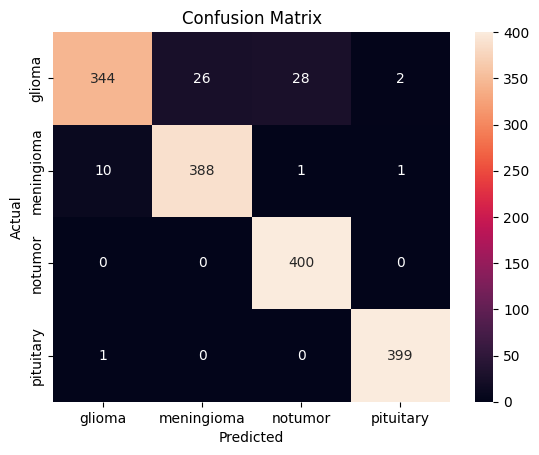

In [21]:
# =============================
# 11. Confusion Matrix
# =============================
cm = confusion_matrix(all_labels, all_preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [22]:

# =============================
# 12. Training Curves
# =============================
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_recalls, label="Val Recall")
plt.legend()
plt.title("Training Progress")
plt.show()

NameError: name 'train_losses' is not defined

<Figure size 640x480 with 0 Axes>

In [ ]:

# =============================
# 13. OPTIONAL: Focal Loss
# =============================
class FocalLoss(nn.Module):
    def __init__(self, gamma=2):
        super().__init__()
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss()

    def forward(self, inputs, targets):
        logp = self.ce(inputs, targets)
        p = torch.exp(-logp)
        return (1 - p) ** self.gamma * logp

criterion = FocalLoss()